# API de Usuários com FastAPI e Pandas

## Visão Geral

Este notebook demonstra um exemplo de construção de uma API REST utilizando FastAPI, desde a análise exploratória dos dados até a implementação e teste dos endpoints.

## Objetivos

1. **Análise Exploratória de Dados**: Carregar e explorar o arquivo `usuarios.json` utilizando Pandas
2. **Processamento de Dados**: Transformar dados aninhados (JSON) em DataFrames estruturados
3. **Construção da API**: Implementar endpoints RESTful com FastAPI
4. **Consumo da API**: Demonstrar como realizar requisições e consumir os dados da API

## Estrutura do Projeto

### Análise de Dados
- Carregamento do arquivo JSON
- Normalização de dados aninhados (equipes, projetos, logs)
- Criação de DataFrames para análise
- Visualizações exploratórias

### Endpoints da API
- `GET /superusers` - Usuários com score ≥ 900 e ativos
- `GET /top-countries` - Top 5 países com mais superusuários
- `GET /team-insights` - Estatísticas por equipe
- `GET /active-users-per-day` - Contagem de logins por dia
- `GET /evaluation` - Avaliação automática da API

### Implementação
- API desenvolvida com FastAPI
- Validação de dados com Pydantic
- Métricas de performance em todas as respostas
- Documentação automática via Swagger

## Fonte de Dados

**Arquivo**: `usuarios.json`  


In [ ]:
# Instalar bibliotecas necessárias:
%pip install pandas matplotlib seaborn
%pip install fastapi uvicorn nest-asyncio requests

In [19]:
# Carregar bibliotecas
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests

print("Bibliotecas importadas com sucesso.")

%pip freeze > requirements.txt

Bibliotecas importadas com sucesso.
Note: you may need to restart the kernel to use updated packages.


#### Importar dados

In [3]:
# Definir o caminho para o seu arquivo JSON.
json_file_path = r"D:/OneDrive/Documentos/GitHub/ciencia-dados-portifolio/API_python/data/usuarios.json"

# Carregar os Dados Brutos do JSON
with open(json_file_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# visualizar
raw_data

[{'id': 'ee8f2662-c8b5-4189-9b66-d6af64fe02be',
  'name': 'Ana Sophia Araújo',
  'age': 19,
  'score': 859,
  'active': True,
  'country': 'Índia',
  'team': {'name': 'Frontend Avengers',
   'leader': False,
   'projects': [{'name': 'Mobile App', 'completed': False}]},
  'logs': [{'date': '2025-03-25', 'action': 'logout'},
   {'date': '2025-03-26', 'action': 'login'},
   {'date': '2025-03-29', 'action': 'logout'},
   {'date': '2025-03-26', 'action': 'login'}]},
 {'id': '1e46c60d-96a4-4bc6-a792-923a0078f3f9',
  'name': 'Sra. Elisa das Neves',
  'age': 44,
  'score': 325,
  'active': True,
  'country': 'Japão',
  'team': {'name': 'UX Wizards',
   'leader': False,
   'projects': [{'name': 'Dashboard', 'completed': True}]},
  'logs': [{'date': '2025-03-27', 'action': 'logout'},
   {'date': '2025-03-31', 'action': 'login'},
   {'date': '2025-03-25', 'action': 'login'}]},
 {'id': 'f1064a79-c486-4672-801c-e688a5f1902d',
  'name': 'Vicente Cavalcanti',
  'age': 40,
  'score': 718,
  'active': 

#### Preparar os Dados para o DataFrame

O JSON possui estruturas aninhadas (team, logs). Para trabalhar eficientemente com Pandas, "achatar" (flatten) esses dados é crucial. Cada log de um usuário se tornará uma linha separada no DataFrame, e as informações da equipe serão transformadas em colunas diretas.

In [4]:

# Inicializa uma lista vazia para armazenar os dados tratados (achatados)
treated_data = []

# Verifica se há dados brutos para processar
if raw_data:
    # Itera sobre cada dicionário de usuário na lista de dados brutos
    for user in raw_data:
        # Cria uma cópia do dicionário do usuário para não modificar o original
        user_copy = user.copy()
        
        # Extrai e remove o dicionário 'team' do usuário, usando um dicionário vazio como padrão se não existir
        team_data = user_copy.pop('team', {})

        # Extrai e remove a lista 'logs' do usuário, usando uma lista vazia como padrão se não existir
        logs_data = user_copy.pop('logs', [])

        # Adiciona as informações da equipe como novas colunas diretas no dicionário do usuário
        user_copy['team_name'] = team_data.get('name')
        user_copy['team_leader'] = team_data.get('leader')
        
        # Mantemos team_projects como uma lista de dicionários aqui, pois não é hashable
        # Isso significa que esta coluna não pode ser usada diretamente em operações como drop_duplicates()
        user_copy['team_projects'] = team_data.get('projects') 

        # Verifica se o usuário tem logs de atividade
        if logs_data:
            # Se tiver logs, itera sobre cada log
            for log in logs_data:
                # Cria uma nova cópia da linha do usuário para cada log
                row = user_copy.copy()
                # Adiciona a data e a ação do log como novas colunas
                row['log_date'] = log.get('date')
                row['log_action'] = log.get('action')
                # Adiciona a linha completa (usuário + log) à lista de dados tratados
                treated_data.append(row)
        else:
            # Se o usuário não tiver logs, ainda assim adiciona uma linha para ele
            # com os campos de log como None para manter a consistência da estrutura
            row = user_copy.copy()
            row['log_date'] = None
            row['log_action'] = None
            treated_data.append(row)
    # Imprime uma mensagem de depuração indicando quantas linhas foram criadas para o DataFrame
    print(f"DEBUG: Dados tratados. Criadas {len(treated_data)} linhas para o DataFrame.")
else:
    # Imprime um aviso se não houver dados brutos para normalizar
    print("AVISO: 'raw_data' está vazio. Nenhuma normalização será realizada.")

# Cria o DataFrame Pandas a partir da lista de dicionários tratados
users_df = pd.DataFrame(treated_data)
# Imprime uma mensagem de depuração mostrando o número inicial de linhas no DataFrame
print(f"DEBUG: DataFrame inicial criado com {len(users_df)} linhas.")

# visualizar
users_df

DEBUG: Dados tratados. Criadas 299811 linhas para o DataFrame.
DEBUG: DataFrame inicial criado com 299811 linhas.


,id,name,age,score,active,country,team_name,team_leader,team_projects,log_date,log_action
0,ee8f2662-c8b5-4189-9b66-d6af64fe02be,Ana Sophia Araújo,19,859,True,Índia,Frontend Avengers,False,"[{'name': 'Mobile App', 'completed': False}]",2025-03-25,logout
1,ee8f2662-c8b5-4189-9b66-d6af64fe02be,Ana Sophia Araújo,19,859,True,Índia,Frontend Avengers,False,"[{'name': 'Mobile App', 'completed': False}]",2025-03-26,login
2,ee8f2662-c8b5-4189-9b66-d6af64fe02be,Ana Sophia Araújo,19,859,True,Índia,Frontend Avengers,False,"[{'name': 'Mobile App', 'completed': False}]",2025-03-29,logout
3,ee8f2662-c8b5-4189-9b66-d6af64fe02be,Ana Sophia Araújo,19,859,True,Índia,Frontend Avengers,False,"[{'name': 'Mobile App', 'completed': False}]",2025-03-26,login
4,1e46c60d-96a4-4bc6-a792-923a0078f3f9,Sra. Elisa das Neves,44,325,True,Japão,UX Wizards,False,"[{'name': 'Dashboard', 'completed': True}]",2025-03-27,logout
...,...,...,...,...,...,...,...,...,...,...,...
299806,febf280b-3752-41ca-8d52-b6ad361ceb74,Heitor Cardoso,23,180,True,México,UX Wizards,False,"[{'name': 'API Pública', 'completed': False}, ...",2025-03-29,logout
299807,137a83d8-d936-4f6c-b999-874511410593,Benício Souza,43,706,True,Índia,Frontend Avengers,False,"[{'name': 'Sistema Interno', 'completed': Fals...",2025-03-25,login
299808,137a83d8-d936-4f6c-b999-874511410593,Benício Souza,43,706,True,Índia,Frontend Avengers,False,"[{'name': 'Sistema Interno', 'completed': Fals...",2025-03-30,login
299809,137a83d8-d936-4f6c-b999-874511410593,Benício Souza,43,706,True,Índia,Frontend Avengers,False,"[{'name': 'Sistema Interno', 'completed': Fals...",2025-03-26,login


#### Mais informações do df

In [5]:
print("\nInformações do DataFrame:")
users_df.info()


Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299811 entries, 0 to 299810
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             299811 non-null  object
 1   name           299811 non-null  object
 2   age            299811 non-null  int64 
 3   score          299811 non-null  int64 
 4   active         299811 non-null  bool  
 5   country        299811 non-null  object
 6   team_name      299811 non-null  object
 7   team_leader    299811 non-null  bool  
 8   team_projects  299811 non-null  object
 9   log_date       299811 non-null  object
 10  log_action     299811 non-null  object
dtypes: bool(2), int64(2), object(7)
memory usage: 21.2+ MB


#### Estatísticas descritivas

In [6]:
print("\nEstatísticas Descritivas para colunas numéricas:")
print(users_df.describe().T)


Estatísticas Descritivas para colunas numéricas:
          count        mean         std    min    25%    50%    75%     max
age    299811.0   41.495836   13.800679   18.0   30.0   42.0   53.0    65.0
score  299811.0  551.789104  260.073296  100.0  328.0  552.0  777.0  1000.0


#### Frequência da coluna 'country'


Frequência da coluna 'country':
country
EUA          30724
México       30212
Índia        30037
Austrália    30012
França       29981
Canadá       29894
Alemanha     29892
Japão        29878
Argentina    29735
Brasil       29446
Name: count, dtype: int64

 Gráfico Frequência da coluna 'country':


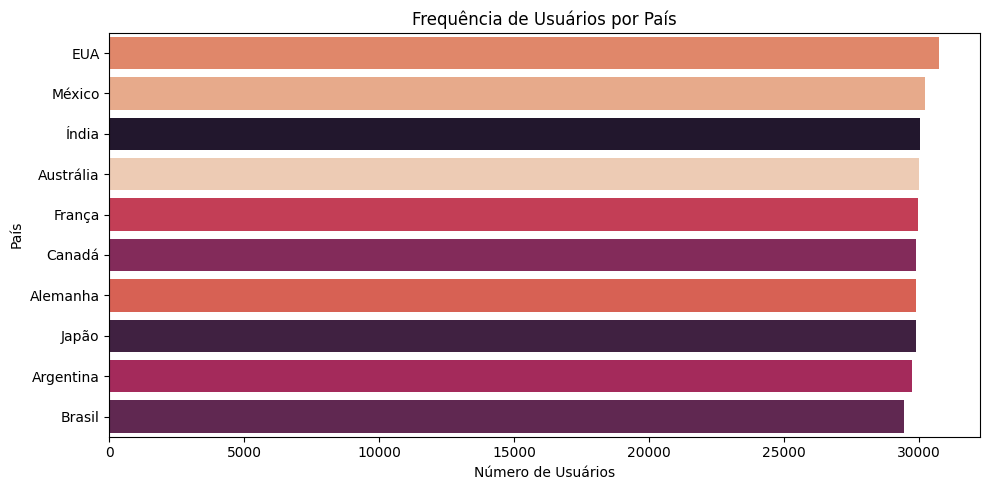

In [7]:
print("\nFrequência da coluna 'country':")
print(users_df['country'].value_counts())

print("\n Gráfico Frequência da coluna 'country':")

# Visualização da frequência de países
plt.figure(figsize=(10, 5))
sns.countplot(
    y='country',
    data=users_df,
    order=users_df['country'].value_counts().index,
    hue='country',
    palette='rocket',
    legend=False
)
plt.title('Frequência de Usuários por País')
plt.xlabel('Número de Usuários')
plt.ylabel('País')
plt.tight_layout()
plt.show()

#### Frequência da coluna 'team_name'


Frequência da coluna 'team_name':
team_name
Fullstack Force      60260
UX Wizards           60057
Frontend Avengers    59921
DevOps Masters       59887
Backend Ninjas       59686
Name: count, dtype: int64

Gráfico Frequência da coluna 'team_name':


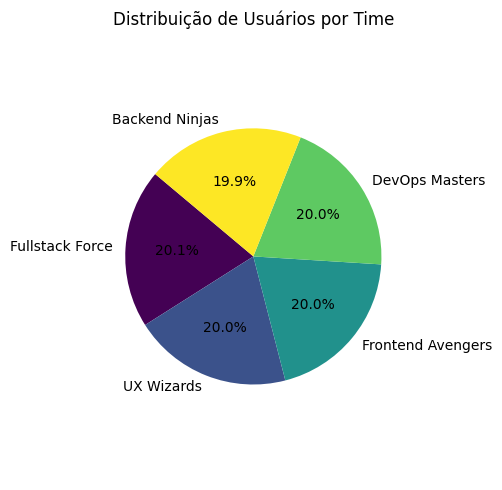

In [8]:
print("\nFrequência da coluna 'team_name':")
team_counts = users_df['team_name'].value_counts()
print(team_counts)

print("\nGráfico Frequência da coluna 'team_name':")

# Gráfico de pizza
plt.figure(figsize=(5, 5))
plt.pie(
    team_counts,
    labels=team_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.viridis(np.linspace(0, 1, len(team_counts)))
)
plt.title('Distribuição de Usuários por Time')
plt.axis('equal')  # Deixa o círculo proporcional
plt.tight_layout()
plt.show()

#### Frequência da coluna 'log_action'


Frequência da coluna 'log_action':
log_action
login     240018
logout     59793
Name: count, dtype: int64

 Gráfico Frequência da coluna 'log_action':


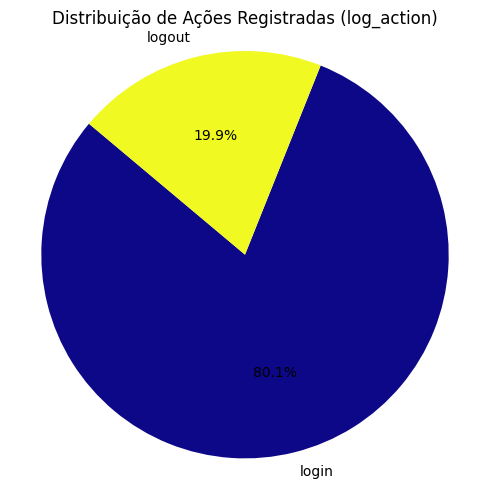

In [9]:
print("\nFrequência da coluna 'log_action':")
action_counts = users_df['log_action'].value_counts()
print(action_counts)

print("\n Gráfico Frequência da coluna 'log_action':")
# Gráfico de pizza
plt.figure(figsize=(5, 5))
plt.pie(
    action_counts,
    labels=action_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.plasma(np.linspace(0, 1, len(action_counts)))
)
plt.title("Distribuição de Ações Registradas (log_action)")
plt.axis('equal')  # Garante um gráfico circular
plt.tight_layout()
plt.show()

### Elaborando os Endpoints da API

Esta seção demonstra como gerar os dados para cada endpoint da API, utilizando o DataFrame users_df.

#### Detalhes da API que vamos construir

**Endpoints**

**POST /users**
Recebe e armazena os usuários na memória. Pode simular um banco de dados em memória.

**GET /superusers**
* Filtro: score >= 900 e active = true
* Retorna os dados e o tempo de processamento da requisição.

**GET /top-countries**
* Agrupa os superusuários por país.
* Retorna os 5 países com maior número de superusuários.

**GET /team-insights**
* Agrupa por team.name.
* Retorna: total de membros, líderes, projetos concluídos e % de membros ativos.

**GET /active-users-per-day**
* Conta quantos logins aconteceram por data.
* Query param opcional: ?min=3000 para filtrar dias com pelo menos 3.000 logins.

**GET /evaluation**
Ele deve executar uma autoavaliação dos principais endpoints da API e retornar um relatório de pontuação.
A avaliação deve testar:
* Se o status retornado é 200
* O tempo em milisegundos de resposta
* Se o retorno é um JSON válido
Esse endpoint pode rodar scripts de teste embutidos no próprio projeto e retornar um JSON com os resultados. Ele será utilizado para validar a entrega de forma automática e rápida.

**Requisitos Técnicos**
* Tempo de resposta < 1s por endpoint.
* Todos os endpoints precisam retornar o tempo de processamento (em milissegundos) e a timestamp da requisição
* Código limpo, modular, com funções bem definidas.
* Pode usar qualquer linguagem/framework.
* Documentação ou explicação final vale pontos bônus.

**A API trata os seguintes cenários:**
- **400 Bad Request**: Dados inválidos ou usuário duplicado
- **404 Not Found**: Recurso não encontrado
- **422 Unprocessable Entity**: Erro de validação Pydantic
- **500 Internal Server Error**: Erros internos do servidor

**Logs e Monitoramento, cada resposta deve incluir:**

- **processing_time_ms**: Tempo de processamento em milissegundos
- **timestamp**: Timestamp ISO 8601 da resposta
- **Validação automática**: Via Pydantic models

#### **GET /superusers**

Retorna usuários com score >= 900 e active = true.

In [10]:
superusers_df = users_df[(users_df['score'] >= 900) & (users_df['active'] == True)] if not users_df.empty else users_df.copy()
unique_users_df = superusers_df.drop_duplicates(subset=['id'])

print("\nSuperusuários (ID, Nome, Score, Ativo, País):")
print(unique_users_df[['id', 'name', 'score', 'active', 'country']].head() 
      if not unique_users_df.empty 
      else "Nenhum dado de usuário carregado para analisar superusuários.")
print(f"Total de Superusuários: {len(unique_users_df)}")


Superusuários (ID, Nome, Score, Ativo, País):
                                       id                      name  score  \
58   c5cf0168-2ad6-405e-a384-8c38563cf40a         Emanuella Barbosa    971   
76   e0053770-9744-4cb6-b896-d9b725cd48b3                Bruno Dias    984   
98   72545b46-31eb-4856-8fc4-2bd36d13f96b  Lucas Gabriel Nascimento    950   
119  30dfde7c-9e08-4b28-9ccd-b5e34956090a             Melissa Ramos    950   
155  58e5316a-70ac-4d42-b039-04320a584c2f              Eloah Vieira    911   

     active    country  
58     True  Austrália  
76     True      Índia  
98     True  Argentina  
119    True        EUA  
155    True  Austrália  
Total de Superusuários: 10132


#### **GET /top-countries** 

Retorna os 5 países com maior número de superusuários.


Top 5 Países com Mais Superusuários:
  country  total
0  Canadá   1057
1  França   1050
2   Índia   1042
3     EUA   1042
4  México   1020

Gráfico Top 5 Países com Mais Superusuários:


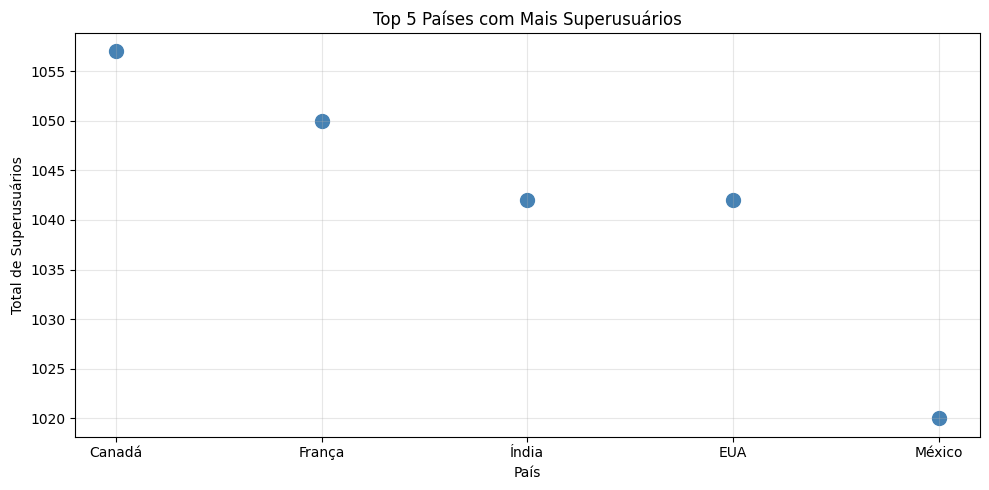

In [11]:
# Análise de países com operador ternário
country_counts = (unique_users_df['country'].value_counts().reset_index())
                 
# Renomear colunas se há dados
country_counts.columns = ['country', 'total'] 
top_5_countries = country_counts.head(5) 

# Print com operador ternário
print("\nTop 5 Países com Mais Superusuários:") 
print(top_5_countries)

# Gráfico com cor única - sem warning - SEM informações extras
print("\nGráfico Top 5 Países com Mais Superusuários:")
plt.figure(figsize=(10, 5))
plt.scatter(top_5_countries['country'], top_5_countries['total'], s=100, color='steelblue')
plt.xlabel('País')
plt.ylabel('Total de Superusuários')
plt.title('Top 5 Países com Mais Superusuários')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();


#### **GET /team-insights**

Agrupa por equipe e retorna estatísticas detalhadas.

**CRIAR DATAFRAME COM ESTATÍSTICAS BÁSICAS**

In [12]:
# Remover duplicados
unique_users_df = users_df.drop_duplicates(subset=['id'])

# Agrupar por equipe e calcular estatísticas simples (sem projetos ainda)
basic_stats = unique_users_df.groupby('team_name').agg({
    'id': 'count',           # total de membros
    'team_leader': 'sum',    # quantidade de líderes  
    'active': ['sum', 'mean'] # membros ativos e porcentagem
}).reset_index()

# Renomear colunas para ficar mais claro
basic_stats.columns = ['team', 'total_members', 'leaders', 'active_count', 'active_percentage']

# Converter porcentagem para formato mais legível
basic_stats['active_percentage'] = (basic_stats['active_percentage'] * 100).round(1)

print("\nEstatísticas básicas por equipe:")
print(basic_stats)


Estatísticas básicas por equipe:
                team  total_members  leaders  active_count  active_percentage
0     Backend Ninjas          19868     3007         17899               90.1
1     DevOps Masters          19925     2916         18026               90.5
2  Frontend Avengers          20010     3004         18005               90.0
3    Fullstack Force          20119     2972         18053               89.7
4         UX Wizards          20078     2985         18087               90.1


**CALCULAR PROJETOS COMPLETADOS SEPARADAMENTE**

In [13]:
def contar_projetos_completos(linha):
    projetos = linha['team_projects']

    # Verifica se é uma lista válida de projetos
    if not isinstance(projetos, list):
        return 0

    # Conta os projetos que estão marcados como completos
    # Usamos isinstance() para garantir que estamos lidando com o tipo certo (como dict, list, str, etc.), e assim evitar erros de execução.
    return sum(1 for projeto in projetos if isinstance(projeto, dict) and projeto.get('completed') == True)

# Aplica a função ao DataFrame
# Garante que unique_users_df é uma cópia verdadeira
unique_users_df = unique_users_df.copy()

# Aplica a função de forma segura
unique_users_df.loc[:, 'qtd_projetos_completos'] = unique_users_df.apply(contar_projetos_completos, axis=1)

# Exibe os primeiros resultados
print("\nPrimeiros 5 usuários com contagem de projetos completos:")
print(unique_users_df[['id', 'name', 'team_name', 'qtd_projetos_completos']].head())

unique_users_df


Primeiros 5 usuários com contagem de projetos completos:
                                      id                  name  \
0   ee8f2662-c8b5-4189-9b66-d6af64fe02be     Ana Sophia Araújo   
4   1e46c60d-96a4-4bc6-a792-923a0078f3f9  Sra. Elisa das Neves   
7   f1064a79-c486-4672-801c-e688a5f1902d    Vicente Cavalcanti   
12  32ccb15e-acfa-48c4-b9df-6f416864c737           Sarah Viana   
14  6feaeed1-9be0-44f4-bba4-d96a747503f7       Nicolas Pereira   

            team_name  qtd_projetos_completos  
0   Frontend Avengers                       0  
4          UX Wizards                       1  
7     Fullstack Force                       2  
12  Frontend Avengers                       2  
14    Fullstack Force                       1  


,id,name,age,score,active,country,team_name,team_leader,team_projects,log_date,log_action,qtd_projetos_completos
0,ee8f2662-c8b5-4189-9b66-d6af64fe02be,Ana Sophia Araújo,19,859,True,Índia,Frontend Avengers,False,"[{'name': 'Mobile App', 'completed': False}]",2025-03-25,logout,0
4,1e46c60d-96a4-4bc6-a792-923a0078f3f9,Sra. Elisa das Neves,44,325,True,Japão,UX Wizards,False,"[{'name': 'Dashboard', 'completed': True}]",2025-03-27,logout,1
7,f1064a79-c486-4672-801c-e688a5f1902d,Vicente Cavalcanti,40,718,True,Brasil,Fullstack Force,False,"[{'name': 'Landing Page', 'completed': True}, ...",2025-03-31,login,2
12,32ccb15e-acfa-48c4-b9df-6f416864c737,Sarah Viana,42,384,True,Canadá,Frontend Avengers,False,"[{'name': 'Dashboard', 'completed': True}, {'n...",2025-03-29,login,2
14,6feaeed1-9be0-44f4-bba4-d96a747503f7,Nicolas Pereira,58,804,True,Canadá,Fullstack Force,False,"[{'name': 'Dashboard', 'completed': True}]",2025-03-28,login,1
...,...,...,...,...,...,...,...,...,...,...,...,...
299797,f967e0e8-8a06-47e0-bc9a-191839dca94d,Maria Cecília Barbosa,63,145,True,Japão,Fullstack Force,True,"[{'name': 'Sistema Interno', 'completed': True...",2025-03-25,login,2
299800,14875277-941e-4185-bee7-34dca5b82021,Agatha das Neves,59,557,True,Canadá,UX Wizards,False,"[{'name': 'Sistema Interno', 'completed': Fals...",2025-03-25,login,0
299804,6e064898-85dd-469a-934f-98aa8f2cb075,Heloísa Barros,52,739,True,Austrália,DevOps Masters,False,"[{'name': 'Landing Page', 'completed': True}]",2025-03-25,login,1
299806,febf280b-3752-41ca-8d52-b6ad361ceb74,Heitor Cardoso,23,180,True,México,UX Wizards,False,"[{'name': 'API Pública', 'completed': False}, ...",2025-03-29,logout,1


**AGRUPAR PROJETOS POR EQUIPE**


Projetos completados por equipe:
                team  completed_projects
0     Backend Ninjas               27930
1     DevOps Masters               27913
2  Frontend Avengers               28056
3    Fullstack Force               28043
4         UX Wizards               28212

Gráfico de Projetos Completos por Time:


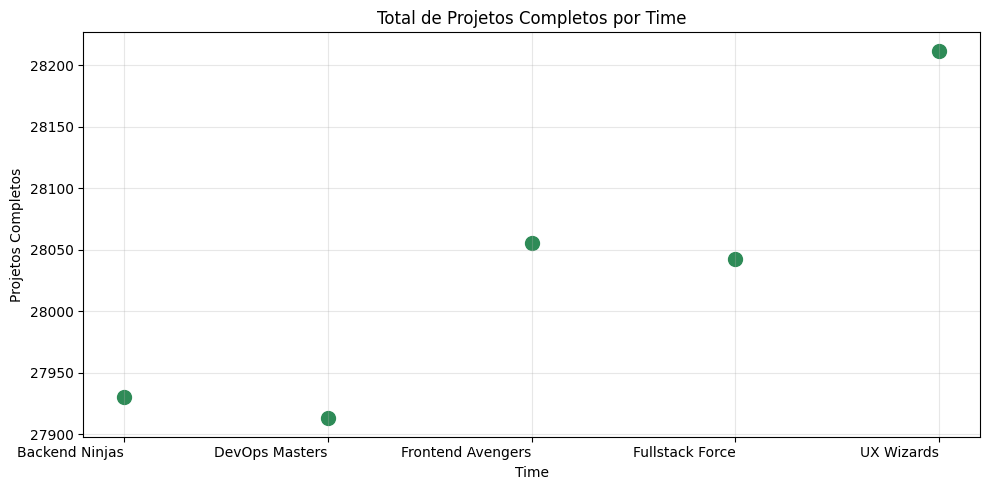

In [14]:
# Somar projetos completados por equipe
projects_by_team = unique_users_df.groupby('team_name')['qtd_projetos_completos'].sum().reset_index()
projects_by_team.columns = ['team', 'completed_projects']

print("\nProjetos completados por equipe:")
print(projects_by_team)

# Gráfico 
print("\nGráfico de Projetos Completos por Time:")
plt.figure(figsize=(10, 5))
plt.scatter(projects_by_team['team'], projects_by_team['completed_projects'], s=100, color='seagreen')
plt.xlabel('Time')
plt.ylabel('Projetos Completos')
plt.title('Total de Projetos Completos por Time')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0, ha='right')  # Rotaciona os nomes dos times para melhor leitura
plt.tight_layout()
plt.show()


**JUNTAR TUDO EM UM DATAFRAME FINAL**

In [15]:
# Fazer merge dos dataframes temporários
team_insights_df = basic_stats.merge(projects_by_team, on='team', how='left')

# Preencher valores nulos com 0 (caso alguma equipe não tenha projetos)
team_insights_df['completed_projects'] = team_insights_df['completed_projects'].fillna(0)

print("\nDataFrame final com todos os insights:")
print(team_insights_df)


DataFrame final com todos os insights:
                team  total_members  leaders  active_count  active_percentage  \
0     Backend Ninjas          19868     3007         17899               90.1   
1     DevOps Masters          19925     2916         18026               90.5   
2  Frontend Avengers          20010     3004         18005               90.0   
3    Fullstack Force          20119     2972         18053               89.7   
4         UX Wizards          20078     2985         18087               90.1   

   completed_projects  
0               27930  
1               27913  
2               28056  
3               28043  
4               28212  


#### **GET /active-users-per-day**

Contar logins por data.


Contagem de Logins por Data:
      date  total
2025-03-25  34325
2025-03-26  34404
2025-03-27  34102
2025-03-28  33970
2025-03-29  34247
2025-03-30  34707
2025-03-31  34263

Gráfico de Logins por Data:


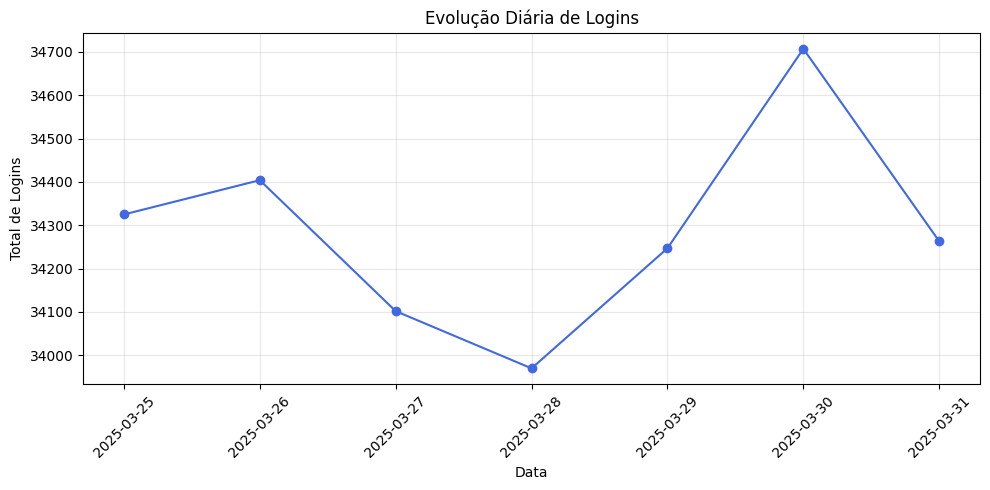

In [16]:
# Filtra logs de login
login_logs_df = users_df[users_df['log_action'] == 'login'].dropna(subset=['log_date'])

# Converte log_date para datetime
login_logs_df['log_date'] = pd.to_datetime(login_logs_df['log_date'])

# Processa os dados de login
logins_by_date = login_logs_df.groupby(login_logs_df['log_date'].dt.date).size().reset_index(name='total')
logins_by_date.columns = ['date', 'total']
logins_by_date['date'] = pd.to_datetime(logins_by_date['date'])
logins_by_date = logins_by_date.sort_values(by='date')

# Exibe os resultados
print("\nContagem de Logins por Data:")
print(logins_by_date.to_string(index=False))

# gráfico
print("\nGráfico de Logins por Data:")
plt.figure(figsize=(10, 5))
plt.plot(logins_by_date['date'], logins_by_date['total'], color='royalblue', marker='o', linestyle='-')
plt.xlabel('Data')
plt.ylabel('Total de Logins')
plt.title('Evolução Diária de Logins')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

______________________
## Construção da API

In [22]:
from fastapi import FastAPI, HTTPException, Query
from typing import Optional
from datetime import datetime
import time
import nest_asyncio
import uvicorn
from threading import Thread

In [24]:
nest_asyncio.apply()

app = FastAPI(title="Users API")

@app.get("/superusers")
def get_superusers():
    start_time = time.time()
    
    if 'superusers_df' not in globals() or users_df.empty:
        raise HTTPException(status_code=404, detail="Nenhum usuário carregado")
    
    if 'unique_users_df' not in globals():
        raise HTTPException(status_code=404, detail="Execute o processamento antes")
    
    result = unique_users_df[['id', 'name', 'score', 'active', 'country']].to_dict('records')
    processing_time = (time.time() - start_time) * 1000
    
    return {
        "data": result,
        "total": len(result),
        "processing_time_ms": round(processing_time, 2),
        "timestamp": datetime.now().isoformat()
    }

@app.get("/top-countries")
def get_top_countries():
    start_time = time.time()
    
    if 'top_5_countries' not in globals():
        raise HTTPException(status_code=404, detail="Execute o processamento antes")
    
    result = top_5_countries.to_dict('records')
    processing_time = (time.time() - start_time) * 1000
    
    return {
        "data": result,
        "processing_time_ms": round(processing_time, 2),
        "timestamp": datetime.now().isoformat()
    }

@app.get("/team-insights")
def get_team_insights():
    start_time = time.time()
    
    if 'team_insights_df' not in globals():
        raise HTTPException(status_code=404, detail="Execute o processamento antes")
    
    result = team_insights_df.to_dict('records')
    processing_time = (time.time() - start_time) * 1000
    
    return {
        "data": result,
        "processing_time_ms": round(processing_time, 2),
        "timestamp": datetime.now().isoformat()
    }

@app.get("/active-users-per-day")
def get_active_users_per_day(min: Optional[int] = Query(None, ge=0)):
    start_time = time.time()
    
    if 'logins_by_date' not in globals():
        raise HTTPException(status_code=404, detail="Execute o processamento antes")
    
    data = logins_by_date.copy()
    
    if min is not None:
        data = data[data['total'] >= min]
    
    data['date'] = data['date'].dt.strftime('%Y-%m-%d')
    result = data.to_dict('records')
    processing_time = (time.time() - start_time) * 1000
    
    return {
        "data": result,
        "filter": {"min": min} if min else None,
        "processing_time_ms": round(processing_time, 2),
        "timestamp": datetime.now().isoformat()
    }

@app.get("/evaluation")
def evaluate_api():
    start_time = time.time()
    
    from fastapi.testclient import TestClient
    client = TestClient(app)
    
    results = []
    endpoints = [
        ("/superusers", "GET"),
        ("/top-countries", "GET"),
        ("/team-insights", "GET"),
        ("/active-users-per-day", "GET")
    ]
    
    for endpoint, method in endpoints:
        try:
            response = client.get(endpoint)
            endpoint_time = response.json().get('processing_time_ms', 0)
            
            results.append({
                "endpoint": endpoint,
                "status": response.status_code,
                "passed": response.status_code == 200,
                "response_time_ms": endpoint_time,
                "is_json": response.headers.get('content-type') == 'application/json'
            })
        except Exception as e:
            results.append({
                "endpoint": endpoint,
                "status": 500,
                "passed": False,
                "error": str(e)
            })
    
    passed = sum(1 for r in results if r.get('passed', False))
    total = len(results)
    score = (passed / total * 100) if total > 0 else 0
    
    processing_time = (time.time() - start_time) * 1000
    
    return {
        "score": round(score, 2),
        "passed": passed,
        "total": total,
        "results": results,
        "processing_time_ms": round(processing_time, 2),
        "timestamp": datetime.now().isoformat()
    }

@app.get("/")
def root():
    return {
        "message": "Users API",
        "endpoints": [
            "GET /superusers",
            "GET /top-countries",
            "GET /team-insights",
            "GET /active-users-per-day",
            "GET /evaluation"
        ]
    }

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="error")

print("Iniciando servidor...")
thread = Thread(target=run_server, daemon=True)
thread.start()

import time
time.sleep(2)  # Aguarda 2 segundos para o servidor iniciar

print("✓ Servidor rodando em: http://127.0.0.1:8000")
print("✓ Documentação em: http://127.0.0.1:8000/docs")

Iniciando servidor...


ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8000): normalmente é permitida apenas uma utilização de cada endereço de soquete (protocolo/endereço de rede/porta)


✓ Servidor rodando em: http://127.0.0.1:8000
✓ Documentação em: http://127.0.0.1:8000/docs


----------------
## Consumindo dados da API

In [25]:
import requests
import json

BASE_URL = "http://127.0.0.1:8000"

def testar_conexao():
    try:
        response = requests.get(f"{BASE_URL}/")
        print("✓ API está rodando!")
        print(json.dumps(response.json(), indent=2, ensure_ascii=False))
        return True
    except requests.exceptions.ConnectionError:
        print("✗ API não está rodando. Execute o servidor primeiro!")
        return False

def get_superusers():
    response = requests.get(f"{BASE_URL}/superusers")
    data = response.json()
    
    print(f"\n=== SUPERUSUÁRIOS ===")
    print(f"Total: {data['total']}")
    print(f"Tempo: {data['processing_time_ms']}ms")
    print(f"\nPrimeiros 5:")
    for user in data['data'][:5]:
        print(f"  [{user['id']}] {user['name']} - Score: {user['score']} ({user['country']})")
    
    return data

def get_top_countries():
    response = requests.get(f"{BASE_URL}/top-countries")
    data = response.json()
    
    print(f"\n=== TOP 5 PAÍSES ===")
    print(f"Tempo: {data['processing_time_ms']}ms")
    for country in data['data']:
        print(f"  {country['country']}: {country['total']} superusuários")
    
    return data

def get_team_insights():
    response = requests.get(f"{BASE_URL}/team-insights")
    data = response.json()
    
    print(f"\n=== INSIGHTS POR TIME ===")
    print(f"Tempo: {data['processing_time_ms']}ms\n")
    for team in data['data']:
        print(f"Time: {team['team']}")
        print(f"  Membros: {team['total_members']}")
        print(f"  Líderes: {team['leaders']}")
        print(f"  Projetos completos: {team['completed_projects']}")
        print(f"  % Ativos: {team['active_percentage']}%\n")
    
    return data

def get_active_users_per_day(min_logins=None):
    url = f"{BASE_URL}/active-users-per-day"
    if min_logins:
        url += f"?min={min_logins}"
    
    response = requests.get(url)
    data = response.json()
    
    print(f"\n=== LOGINS POR DIA ===")
    if min_logins:
        print(f"Filtro: mínimo {min_logins} logins")
    print(f"Total de dias: {len(data['data'])}")
    print(f"Tempo: {data['processing_time_ms']}ms\n")
    
    print("Primeiros 10 dias:")
    for login in data['data'][:10]:
        print(f"  {login['date']}: {login['total']} logins")
    
    return data

def get_evaluation():
    response = requests.get(f"{BASE_URL}/evaluation")
    data = response.json()
    
    print(f"\n=== AVALIAÇÃO DA API ===")
    print(f"Score: {data['score']}%")
    print(f"Passou: {data['passed']}/{data['total']}")
    print(f"Tempo: {data['processing_time_ms']}ms\n")
    
    print("Resultados dos testes:")
    for r in data['results']:
        status = "✓" if r['passed'] else "✗"
        print(f"  {status} {r['endpoint']}")
        print(f"     Status: {r['status']}")
        print(f"     Tempo: {r['response_time_ms']}ms")
        print(f"     JSON válido: {r['is_json']}\n")
    
    return data

def testar_todos_endpoints():
    if not testar_conexao():
        return
    
    get_superusers()
    get_top_countries()
    get_team_insights()
    get_active_users_per_day()
    get_active_users_per_day(min_logins=3000)
    get_evaluation()

print("Funções disponíveis:")
print("  testar_conexao() - Verifica se a API está rodando")
print("  get_superusers() - Lista superusuários")
print("  get_top_countries() - Top 5 países")
print("  get_team_insights() - Insights por time")
print("  get_active_users_per_day(min_logins=None) - Logins por dia")
print("  get_evaluation() - Avaliação da API")
print("  testar_todos_endpoints() - Testa tudo de uma vez")
print("\nExemplo de uso:")
print("  testar_todos_endpoints()")

Funções disponíveis:
  testar_conexao() - Verifica se a API está rodando
  get_superusers() - Lista superusuários
  get_top_countries() - Top 5 países
  get_team_insights() - Insights por time
  get_active_users_per_day(min_logins=None) - Logins por dia
  get_evaluation() - Avaliação da API
  testar_todos_endpoints() - Testa tudo de uma vez

Exemplo de uso:
  testar_todos_endpoints()


In [26]:
# Testar tudo de uma vez
testar_todos_endpoints()

✓ API está rodando!
{
  "message": "Users API",
  "endpoints": [
    "GET /superusers",
    "GET /top-countries",
    "GET /team-insights",
    "GET /active-users-per-day",
    "GET /evaluation"
  ]
}

=== SUPERUSUÁRIOS ===
Total: 100000
Tempo: 219.46ms

Primeiros 5:
  [ee8f2662-c8b5-4189-9b66-d6af64fe02be] Ana Sophia Araújo - Score: 859 (Índia)
  [1e46c60d-96a4-4bc6-a792-923a0078f3f9] Sra. Elisa das Neves - Score: 325 (Japão)
  [f1064a79-c486-4672-801c-e688a5f1902d] Vicente Cavalcanti - Score: 718 (Brasil)
  [32ccb15e-acfa-48c4-b9df-6f416864c737] Sarah Viana - Score: 384 (Canadá)
  [6feaeed1-9be0-44f4-bba4-d96a747503f7] Nicolas Pereira - Score: 804 (Canadá)

=== TOP 5 PAÍSES ===
Tempo: 0.0ms
  Canadá: 1057 superusuários
  França: 1050 superusuários
  Índia: 1042 superusuários
  EUA: 1042 superusuários
  México: 1020 superusuários

=== INSIGHTS POR TIME ===
Tempo: 1.0ms

Time: Backend Ninjas
  Membros: 19868
  Líderes: 3007
  Projetos completos: 27930
  % Ativos: 90.1%

Time: DevOps Ma

In [28]:
# Testar conexão primeiro
testar_conexao()

✓ API está rodando!
{
  "message": "Users API",
  "endpoints": [
    "GET /superusers",
    "GET /top-countries",
    "GET /team-insights",
    "GET /active-users-per-day",
    "GET /evaluation"
  ]
}


True

In [ ]:
# Testar endpoint get_superusers
get_superusers()



=== SUPERUSUÁRIOS ===
Total: 100000
Tempo: 204.1ms

Primeiros 5:
  [ee8f2662-c8b5-4189-9b66-d6af64fe02be] Ana Sophia Araújo - Score: 859 (Índia)
  [1e46c60d-96a4-4bc6-a792-923a0078f3f9] Sra. Elisa das Neves - Score: 325 (Japão)
  [f1064a79-c486-4672-801c-e688a5f1902d] Vicente Cavalcanti - Score: 718 (Brasil)
  [32ccb15e-acfa-48c4-b9df-6f416864c737] Sarah Viana - Score: 384 (Canadá)
  [6feaeed1-9be0-44f4-bba4-d96a747503f7] Nicolas Pereira - Score: 804 (Canadá)


{'data': [{'id': 'ee8f2662-c8b5-4189-9b66-d6af64fe02be',
   'name': 'Ana Sophia Araújo',
   'score': 859,
   'active': True,
   'country': 'Índia'},
  {'id': '1e46c60d-96a4-4bc6-a792-923a0078f3f9',
   'name': 'Sra. Elisa das Neves',
   'score': 325,
   'active': True,
   'country': 'Japão'},
  {'id': 'f1064a79-c486-4672-801c-e688a5f1902d',
   'name': 'Vicente Cavalcanti',
   'score': 718,
   'active': True,
   'country': 'Brasil'},
  {'id': '32ccb15e-acfa-48c4-b9df-6f416864c737',
   'name': 'Sarah Viana',
   'score': 384,
   'active': True,
   'country': 'Canadá'},
  {'id': '6feaeed1-9be0-44f4-bba4-d96a747503f7',
   'name': 'Nicolas Pereira',
   'score': 804,
   'active': True,
   'country': 'Canadá'},
  {'id': '0c9858d8-7085-4280-b089-2b6250184ee3',
   'name': 'Antônio Carvalho',
   'score': 771,
   'active': True,
   'country': 'Argentina'},
  {'id': 'fd91d8cf-57dd-483c-b1d7-b2ed224d1579',
   'name': 'Enzo Santos',
   'score': 742,
   'active': True,
   'country': 'França'},
  {'id':

In [30]:
# Testar endpoint get_top_countries
get_top_countries()


=== TOP 5 PAÍSES ===
Tempo: 1.0ms
  Canadá: 1057 superusuários
  França: 1050 superusuários
  Índia: 1042 superusuários
  EUA: 1042 superusuários
  México: 1020 superusuários


{'data': [{'country': 'Canadá', 'total': 1057},
  {'country': 'França', 'total': 1050},
  {'country': 'Índia', 'total': 1042},
  {'country': 'EUA', 'total': 1042},
  {'country': 'México', 'total': 1020}],
 'processing_time_ms': 1.0,
 'timestamp': '2025-10-09T10:09:52.016846'}

In [ ]:
# Testar endpoint get_team_insights
get_team_insights()


=== INSIGHTS POR TIME ===
Tempo: 1.51ms

Time: Backend Ninjas
  Membros: 19868
  Líderes: 3007
  Projetos completos: 27930
  % Ativos: 90.1%

Time: DevOps Masters
  Membros: 19925
  Líderes: 2916
  Projetos completos: 27913
  % Ativos: 90.5%

Time: Frontend Avengers
  Membros: 20010
  Líderes: 3004
  Projetos completos: 28056
  % Ativos: 90.0%

Time: Fullstack Force
  Membros: 20119
  Líderes: 2972
  Projetos completos: 28043
  % Ativos: 89.7%

Time: UX Wizards
  Membros: 20078
  Líderes: 2985
  Projetos completos: 28212
  % Ativos: 90.1%



{'data': [{'team': 'Backend Ninjas',
   'total_members': 19868,
   'leaders': 3007,
   'active_count': 17899,
   'active_percentage': 90.1,
   'completed_projects': 27930},
  {'team': 'DevOps Masters',
   'total_members': 19925,
   'leaders': 2916,
   'active_count': 18026,
   'active_percentage': 90.5,
   'completed_projects': 27913},
  {'team': 'Frontend Avengers',
   'total_members': 20010,
   'leaders': 3004,
   'active_count': 18005,
   'active_percentage': 90.0,
   'completed_projects': 28056},
  {'team': 'Fullstack Force',
   'total_members': 20119,
   'leaders': 2972,
   'active_count': 18053,
   'active_percentage': 89.7,
   'completed_projects': 28043},
  {'team': 'UX Wizards',
   'total_members': 20078,
   'leaders': 2985,
   'active_count': 18087,
   'active_percentage': 90.1,
   'completed_projects': 28212}],
 'processing_time_ms': 1.51,
 'timestamp': '2025-10-09T10:10:08.018611'}

In [32]:
# Testar endpoint get_active_users_per_day
get_active_users_per_day()



=== LOGINS POR DIA ===
Total de dias: 7
Tempo: 1.0ms

Primeiros 10 dias:
  2025-03-25: 34325 logins
  2025-03-26: 34404 logins
  2025-03-27: 34102 logins
  2025-03-28: 33970 logins
  2025-03-29: 34247 logins
  2025-03-30: 34707 logins
  2025-03-31: 34263 logins


{'data': [{'date': '2025-03-25', 'total': 34325},
  {'date': '2025-03-26', 'total': 34404},
  {'date': '2025-03-27', 'total': 34102},
  {'date': '2025-03-28', 'total': 33970},
  {'date': '2025-03-29', 'total': 34247},
  {'date': '2025-03-30', 'total': 34707},
  {'date': '2025-03-31', 'total': 34263}],
 'filter': None,
 'processing_time_ms': 1.0,
 'timestamp': '2025-10-09T10:10:55.164579'}

In [35]:
# Testar endpoint get_active_users_per_day
get_active_users_per_day(min_logins=3000)



=== LOGINS POR DIA ===
Filtro: mínimo 3000 logins
Total de dias: 7
Tempo: 2.31ms

Primeiros 10 dias:
  2025-03-25: 34325 logins
  2025-03-26: 34404 logins
  2025-03-27: 34102 logins
  2025-03-28: 33970 logins
  2025-03-29: 34247 logins
  2025-03-30: 34707 logins
  2025-03-31: 34263 logins


{'data': [{'date': '2025-03-25', 'total': 34325},
  {'date': '2025-03-26', 'total': 34404},
  {'date': '2025-03-27', 'total': 34102},
  {'date': '2025-03-28', 'total': 33970},
  {'date': '2025-03-29', 'total': 34247},
  {'date': '2025-03-30', 'total': 34707},
  {'date': '2025-03-31', 'total': 34263}],
 'filter': {'min': 3000},
 'processing_time_ms': 2.31,
 'timestamp': '2025-10-09T10:11:17.760921'}

In [36]:
# Testar endpoint get_evaluation
get_evaluation()


=== AVALIAÇÃO DA API ===
Score: 100.0%
Passou: 4/4
Tempo: 1769.71ms

Resultados dos testes:
  ✓ /superusers
     Status: 200
     Tempo: 210.6ms
     JSON válido: True

  ✓ /top-countries
     Status: 200
     Tempo: 0.0ms
     JSON válido: True

  ✓ /team-insights
     Status: 200
     Tempo: 0.0ms
     JSON válido: True

  ✓ /active-users-per-day
     Status: 200
     Tempo: 1.5ms
     JSON válido: True



{'score': 100.0,
 'passed': 4,
 'total': 4,
 'results': [{'endpoint': '/superusers',
   'status': 200,
   'passed': True,
   'response_time_ms': 210.6,
   'is_json': True},
  {'endpoint': '/top-countries',
   'status': 200,
   'passed': True,
   'response_time_ms': 0.0,
   'is_json': True},
  {'endpoint': '/team-insights',
   'status': 200,
   'passed': True,
   'response_time_ms': 0.0,
   'is_json': True},
  {'endpoint': '/active-users-per-day',
   'status': 200,
   'passed': True,
   'response_time_ms': 1.5,
   'is_json': True}],
 'processing_time_ms': 1769.71,
 'timestamp': '2025-10-09T10:11:28.969440'}